In [ ]:
import pandas as pd
import os


csv_path = os.path.join('raw_data', 'training_solutions_rev1.csv')


df = pd.read_csv(csv_path)


df.head()

,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class9.3,Class10.1,Class10.2,Class10.3,Class11.1,Class11.2,Class11.3,Class11.4,Class11.5,Class11.6
0,100008,0.383147,0.616853,0.000000,0.000000,0.616853,0.038452,0.578401,0.418398,0.198455,...,0.000000,0.279952,0.138445,0.000000,0.000000,0.092886,0.0,0.0,0.0,0.325512
1,100023,0.327001,0.663777,0.009222,0.031178,0.632599,0.467370,0.165229,0.591328,0.041271,...,0.018764,0.000000,0.131378,0.459950,0.000000,0.591328,0.0,0.0,0.0,0.000000
2,100053,0.765717,0.177352,0.056931,0.000000,0.177352,0.000000,0.177352,0.000000,0.177352,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000
3,100078,0.693377,0.238564,0.068059,0.000000,0.238564,0.109493,0.129071,0.189098,0.049466,...,0.000000,0.094549,0.000000,0.094549,0.189098,0.000000,0.0,0.0,0.0,0.000000
4,100090,0.933839,0.000000,0.066161,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000


In [ ]:
# tylko wiersze gdzie pewność ludzi co do typu galaktyki >80%
elliptical_df = df[df['Class1.1'] > 0.8]
spiral_df = df[df['Class1.2'] > 0.8]

#bierzemy tylko po 500 najlepszych zdjęć z każdej kategorii, żeby ułatwić naukę modelu
elliptical_sample = elliptical_df.head(500)
spiral_sample = spiral_df.head(500)

print(f"Wybrano {len(elliptical_sample)} galaktyk eliptycznych")
print(f"Wybrano {len(spiral_sample)} galaktyk spiralnych")

Wybrano 500 galaktyk eliptycznych
Wybrano 500 galaktyk spiralnych


In [ ]:
import shutil

#tworzenie folderow
base_dir = 'data'
os.makedirs(os.path.join(base_dir, 'spiral'), exist_ok=True)
os.makedirs(os.path.join(base_dir, 'elliptical'), exist_ok=True)

#funkcja do kopiowania plików na podstawie wyfiltrowanej tabeli

def copy_images(dataframe, category_name):
    count = 0
    for index, row in dataframe.iterrows():
        #pobieramy nazwę pliku z kolumny GalaxyID
        galaxy_id = str(int(row['GalaxyID']))
        img_name = f"{galaxy_id}.jpg"

        #Ustawiamy ścieżki skąd -> dokąd
        source_path = os.path.join('raw_data', 'images_training_rev1', img_name)
        dest_path = os.path.join(base_dir, category_name, img_name)

        #kopiujemy plik
        if os.path.exists(source_path):
            shutil.copy(source_path, dest_path)
            count += 1

    print(f"Skopiowano {count} zdjęć do folderu data/{category_name}")

copy_images(spiral_sample, 'spiral')
copy_images(elliptical_sample, 'elliptical')

Skopiowano 500 zdjęć do folderu data/spiral
Skopiowano 500 zdjęć do folderu data/elliptical


Oto galaktyka: 100134.jpg


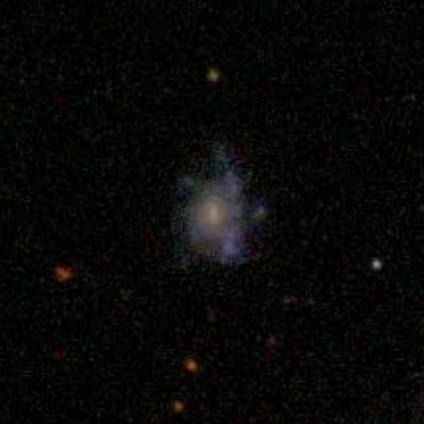

Typ danych: <class 'numpy.ndarray'>
Wymiary (kształt) macierzy: (424, 424, 3)


In [ ]:
from IPython.display import Image as IPyImage, display
from PIL import Image
import numpy as np
import os

# sciezka do pierwszego zdjecia z brzegu
spiral_folder = os.path.join('data', 'spiral')
first_image_name = os.listdir(spiral_folder)[0]
sample_image_path = os.path.join(spiral_folder, first_image_name)

#  Wyświetlamy zdjęcie używając natywnej funkcji notatnika Jupyter
print(f"Oto galaktyka: {first_image_name}")
display(IPyImage(filename=sample_image_path))

#  Ładujemy zdjęcie do pamięci jako macierz liczb
img_pil = Image.open(sample_image_path)
img_array = np.array(img_pil)

print(f"Typ danych: {type(img_array)}")
print(f"Wymiary (kształt) macierzy: {img_array.shape}")

In [ ]:

piksel = img_array[0, 0]

print(f"Wartości RGB dla pierwszego piksela: {piksel}")

Wartości RGB dla pierwszego piksela: [3 0 0]


In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#normalizacja oraz podział zdjęć 80/20
datagen = ImageDataGenerator(
    rescale=1./255, #dzielenie kazdego pikselu przez 255
    validation_split=0.2 #20% zdjęć zostawiamy na testy
)

print("Przygotowuję zbiór treningowy:")
train_generator = datagen.flow_from_directory(
    'data',  #głowny folder z kategoriami
    target_size=(150, 150),  #zmniejszamy rozdzielczosc z 424x424 na 150x150
    batch_size=32,  #pakiety po 32 zdjęcia
    class_mode='categorical',  #mamy więcej niż jedną kategorię
    subset='training'  #bierzemy 80%
)


print("\n Przygotowuję zbiór walidacyjny:")
validation_generator = datagen.flow_from_directory(
    'data',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation' #pozostałe 20% do egzaminowania
)


Przygotowuję zbiór treningowy:
Found 800 images belonging to 2 classes.



 Przygotowuję zbiór walidacyjny:
Found 200 images belonging to 2 classes.


In [ ]:

# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# #CNN

# #Inicjalizacja pustego modelu
# model = Sequential([
#     #1.Blok konwolucyjny (podstawowe kształty)
#     Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
#     MaxPooling2D(2,2),  #Zmniejszamy obraz dwukrotnie, żeby odrzucić zbędne detale

#     #2.Blok konwolucyjny (bardziej skomplikowane kształty)
#     Conv2D(64, (3, 3), activation='relu'),
#     MaxPooling2D(2,2),


#     #3.Blok konwolucyjny (zaawansowane cechy galaktyk)
#     Conv2D(128, (3,3), activation='relu'),
#     MaxPooling2D(2,2),

#     #4. Spłaszczenie wyników
#     Flatten(),

#     #5.Gęsta warstwa neuronów (czyli mózg decyzyjny)
#     Dense(512, activation='relu'),

#     #6. Warstwa wyjściowa - 2 neurony bo mamy dwie klasy
#     Dense(2, activation='softmax')

# ])

# model.summary()

c:\Users\elaka\OneDrive\galaxy-classifier-cnn\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,690 (72.61 MB)

 Trainable params: 19,034,690 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# model.compile(
#     optimizer='adam',
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# print("Model skompilowany i gotowy do startu")

Model skompilowany i gotowy do startu


In [ ]:
# history = model.fit(
#     train_generator,
#     epochs=10,
#     validation_data=validation_generator
# )

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 364ms/step - accuracy: 0.6775 - loss: 0.6107 - val_accuracy: 0.7350 - val_loss: 0.5725
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 219ms/step - accuracy: 0.8562 - loss: 0.3523 - val_accuracy: 0.8300 - val_loss: 0.4480
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 219ms/step - accuracy: 0.9013 - loss: 0.2480 - val_accuracy: 0.8000 - val_loss: 0.4953
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 220ms/step - accuracy: 0.9425 - loss: 0.1731 - val_accuracy: 0.8350 - val_loss: 0.4926
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 217ms/step - accuracy: 0.9538 - loss: 0.1094 - val_accuracy: 0.7850 - val_loss: 0.6319
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 219ms/step - accuracy: 0.9737 - loss: 0.0731 - val_accuracy: 0.7650 - val_loss: 0.9748
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 212ms/step - accuracy: 0.9712 - loss: 0.0788 - val_accuracy: 0.7850 - val_loss: 0.8615
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 216ms/step - accuracy: 0.9750 - loss: 0.0686 - val_accuracy: 0

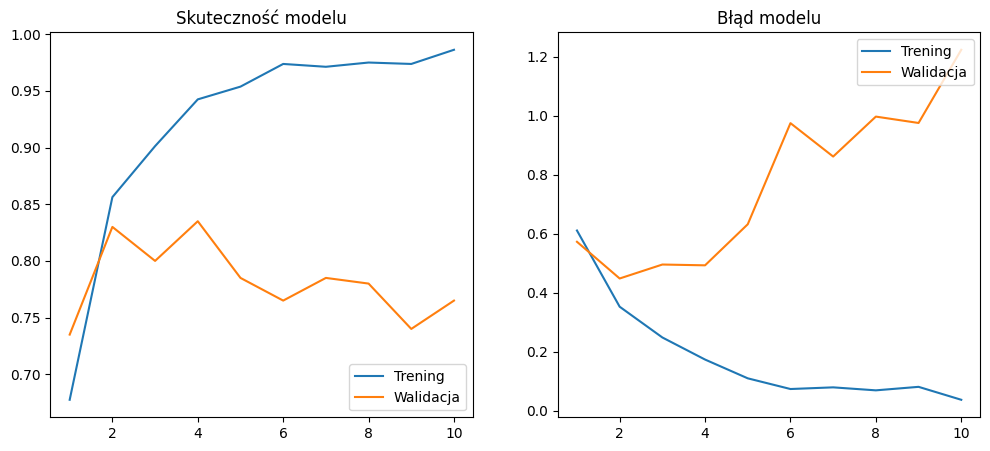

In [14]:
import matplotlib.pyplot as plt

# Wyciągamy dane z historii treningu
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)


plt.figure(figsize=(12, 5))

#skutecznosc
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Trening')
plt.plot(epochs_range, val_acc, label='Walidacja')
plt.legend(loc='lower right')
plt.title('Skuteczność modelu')


#blad
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Trening')
plt.plot(epochs_range, val_loss, label="Walidacja")
plt.legend(loc='upper right')
plt.title("Błąd modelu")

plt.show()

Wyraźnie widać overfitting, model nauczył się zdjęć treningowych na pamięć a na zdjęciach walidacyjnych skuteczność spada i ilość błędów wzrasta


In [27]:
datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40, #losowy obrot zdjec  40 stopni
    width_shift_range=0.2, #przesuniecie w poziomie o 20%
    height_shift_range=0.2, #przesuniecie w pionie o 20% 
    shear_range=0.2, #scinanie obrazu
    zoom_range=0.2, #losowe przyblizanie
    horizontal_flip=True, #odbicie lustrzane
    fill_mode='nearest', #wypelnienie pustych rogow po obrocie
    validation_split=0.2
)

#egzamin
datagen_clean = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

print("Przygotowuję nowe, dynamiczne zbiory danych...")

train_generator_aug = datagen_aug.flow_from_directory(
    'data',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator_clean = datagen_clean.flow_from_directory(
    'data',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Przygotowuję nowe, dynamiczne zbiory danych...
Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


In [29]:
#model_v3

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_v3 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),


    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),


    Flatten(),
    Dense(512, activation='relu'),
    Dense(2, activation='softmax')
])

#kompilacja
model_v3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model gotowy")

Model gotowy


c:\Users\elaka\OneDrive\galaxy-classifier-cnn\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
history_v3 = model_v3.fit(
    train_generator_aug,  
    epochs=15,   #wiecej epok bo trudniejszy material
    validation_data=validation_generator_clean
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 269ms/step - accuracy: 0.6162 - loss: 0.6510 - val_accuracy: 0.5900 - val_loss: 0.8408
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 247ms/step - accuracy: 0.7525 - loss: 0.5311 - val_accuracy: 0.7950 - val_loss: 0.4646
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 243ms/step - accuracy: 0.8050 - loss: 0.4581 - val_accuracy: 0.7900 - val_loss: 0.4662
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 246ms/step - accuracy: 0.7950 - loss: 0.4492 - val_accuracy: 0.8200 - val_loss: 0.4392
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 245ms/step - accuracy: 0.8100 - loss: 0.4408 - val_accuracy: 0.8750 - val_loss: 0.3518
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 246ms/step - accuracy: 0.8475 - loss: 0.3789 - val_accuracy: 0.8350 - val_loss: 0.3938
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 247ms/step - accuracy: 0.8175 - loss: 0.3902 - val_accuracy: 0.8450 - val_loss: 0.3360
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 244ms/step - accuracy: 0.8550 - loss: 0.3546 - val_accuracy: 0.

In [31]:
#zapis modelu
model_v3.save('galaxy_classifier.keras')

print("Model bezpiecznie zapisany na dysku jako 'galaxy_classifier.keras'!")

Model bezpiecznie zapisany na dysku jako 'galaxy_classifier.keras'!


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

def sprawdz_galaktyke(sciezk_do_zdjecia):
    #1. ladujemy zdjecie i zmieniamy rozmiar na 150x150 tak jak nauczyl sie model
    img = image.load_img(sciezk_do_zdjecia, target_size=(150, 150))

    #2. przerabiamy obrazek na macierz i dodajemy dodatkowy wymiar
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)


    #normalizacja pikseli
    img_array = img_array / 255.0

    wynik = model_v3.predict(img_array)
    

    
    
    klasy = list(train_generator_aug.class_indices.keys())

    print("Werdykt...")
    print(f"Prawdopodobieństwo {klasy[0]}: {wynik[0][0] * 100:.2f}%")
    print(f"Prawdopodobieństwo {klasy[1]}: {wynik[0][1] * 100:.2f}%")

    zwyciezca = klasy[np.argmax(wynik[0])]
    print(f"\n=> Według mojego modelu to na pewno: {zwyciezca.upper()}!")


print("Skaner gotowy do użycia!")




Skaner gotowy do użycia!


In [ ]:
import os
import random

#  pobieranie nazw folderów z katalogu 'data'
klasy_galaktyk = [f for f in os.listdir('data') if os.path.isdir(os.path.join('data', f))]

#  Wybranie losowosowej klasy i losowego zdjęcia z jej środka
losowa_klasa = random.choice(klasy_galaktyk)
folder_z_klasa = os.path.join('data', losowa_klasa)
wszystkie_zdjecia = os.listdir(folder_z_klasa)
losowe_zdjecie = random.choice(wszystkie_zdjecia)


testowa_sciezka = os.path.join(folder_z_klasa, losowe_zdjecie)

print(f"Wybrałem losowe zdjęcie z dysku: {testowa_sciezka}")
print("Rozpoczynam analizę modelu V3...")
print("-" * 30)


sprawdz_galaktyke(testowa_sciezka)

Wybrałem losowe zdjęcie z dysku: data\elliptical\139269.jpg
Rozpoczynam analizę modelu V3...
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Werdykt...
Prawdopodobieństwo elliptical: 92.25%
Prawdopodobieństwo spiral: 7.75%

=> Według mojego modelu to na pewno: ELLIPTICAL!
